Features : 11
Train    : 712  |  Test: 179
Columns  : ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone', 'FarePerPerson']

Training BasicNet …
  Stopped after 55 iterations

Training DeepNet …
  Stopped after 43 iterations

────────────────────────────────────────────────
  BasicNet (1 hidden layer)
  Accuracy : 0.7933
  ROC-AUC  : 0.8494
────────────────────────────────────────────────
              precision    recall  f1-score   support

Not Survived       0.80      0.89      0.84       110
    Survived       0.79      0.64      0.70        69

    accuracy                           0.79       179
   macro avg       0.79      0.76      0.77       179
weighted avg       0.79      0.79      0.79       179

────────────────────────────────────────────────
  DeepNet  (5 hidden layers)
  Accuracy : 0.8045
  ROC-AUC  : 0.8648
────────────────────────────────────────────────
              precision    recall  f1-score   support

Not Surv

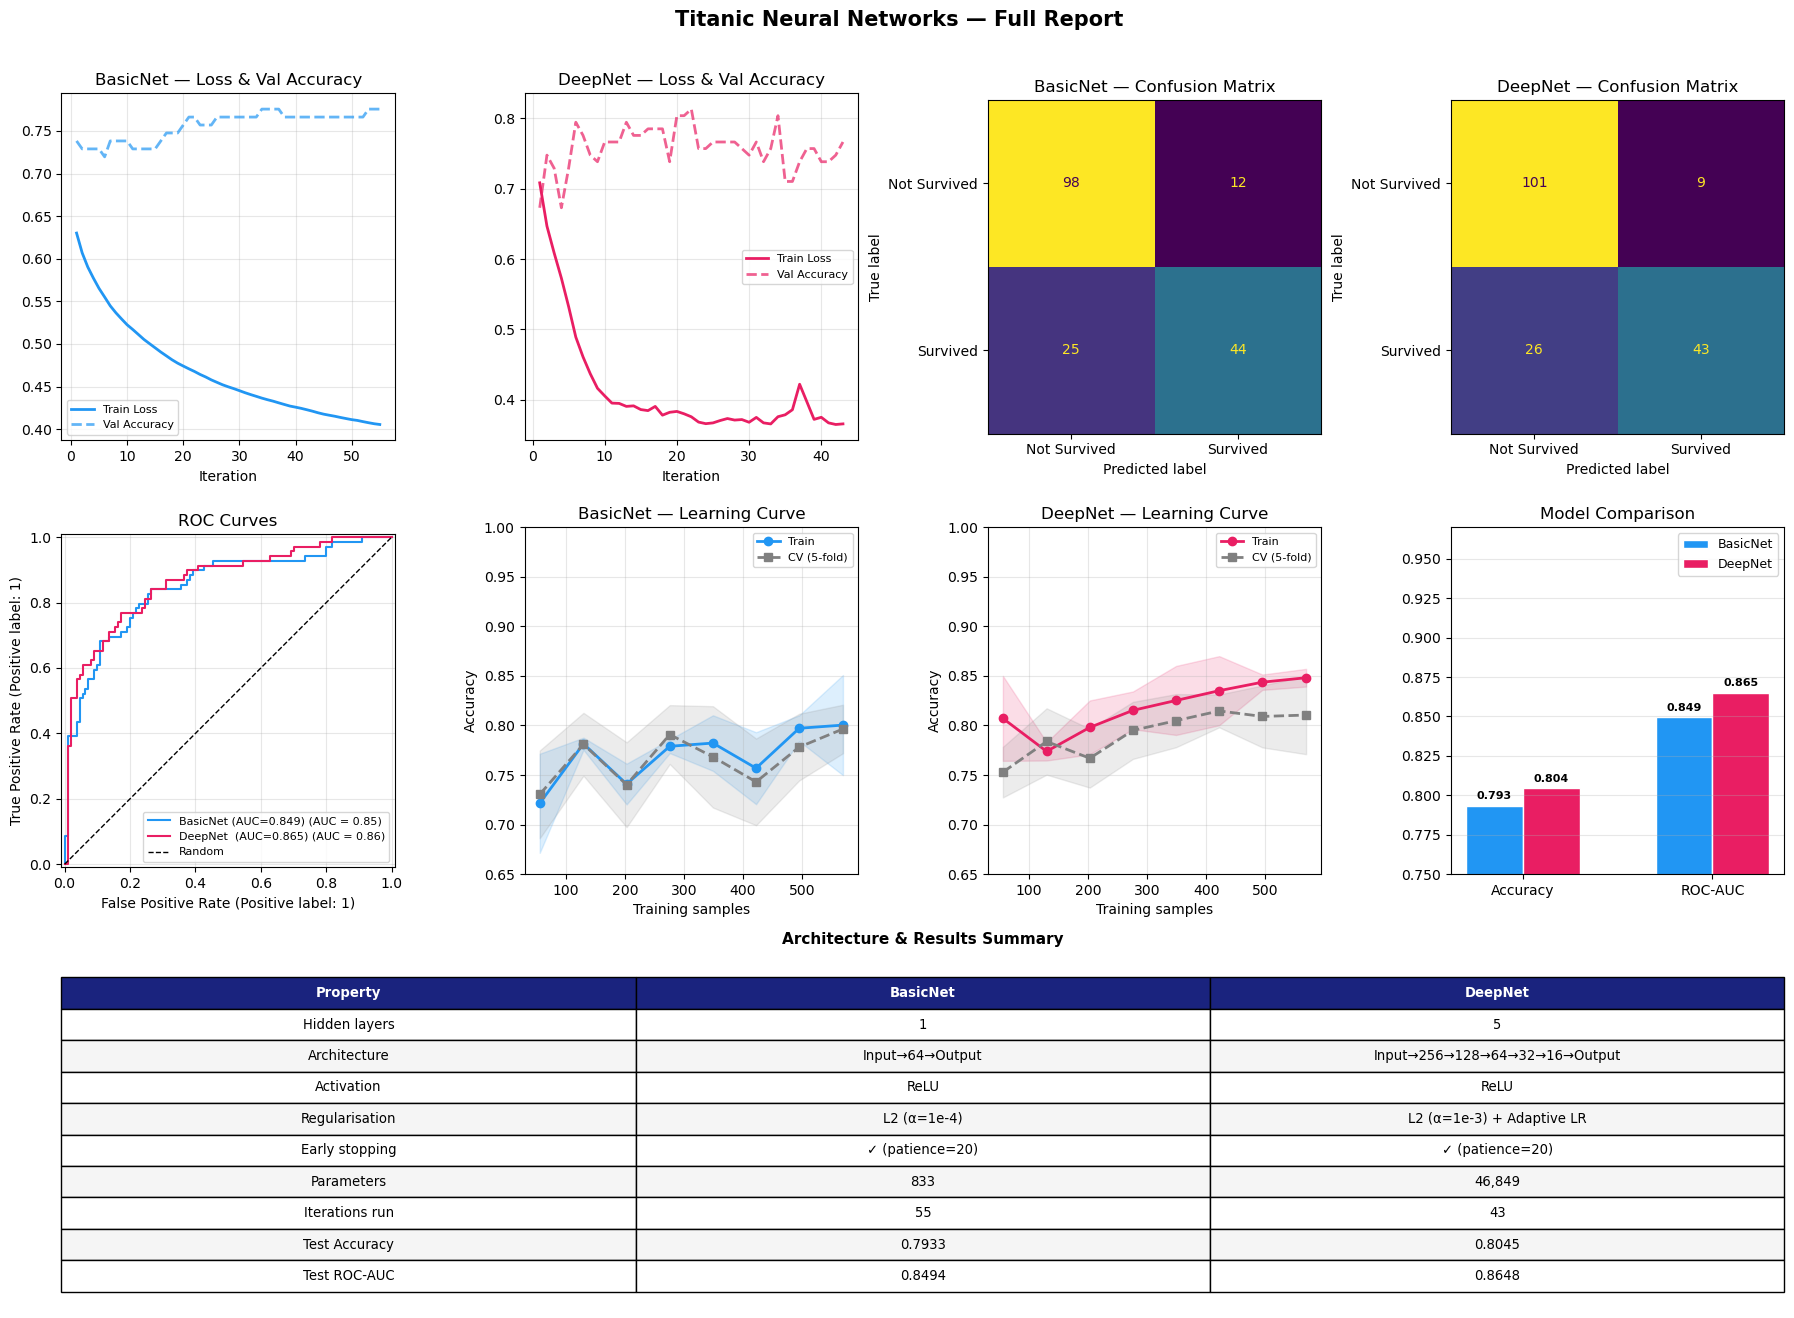

Done — titanic_nn_report.png saved.


In [10]:
"""
Titanic Survival Prediction — Neural Network Models (scikit-learn)
Compatible with JupyterLite / Pyodide (no PyTorch / TensorFlow needed)

Models:
  1. BasicNet  — 1 hidden layer  (64 units)
  2. DeepNet   — 5 hidden layers (256-128-64-32-16)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

np.random.seed(42)

# ─────────────────────────────────────────────────────────
# 1. LOAD & PREPROCESS
# ─────────────────────────────────────────────────────────

df = pd.read_csv("Titanic-Dataset.csv")

# Drop low-signal / high-cardinality columns
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)

# Fill missing values (pandas CoW-safe)
df["Age"]      = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())

# Encode categoricals
df["Sex"] = (df["Sex"] == "female").astype(int)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Feature engineering
df["FamilySize"]    = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]       = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

X = df.drop("Survived", axis=1).values.astype(np.float32)
y = df["Survived"].values

feature_names = df.drop("Survived", axis=1).columns.tolist()

# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardise
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Features : {X.shape[1]}")
print(f"Train    : {len(X_train)}  |  Test: {len(X_test)}")
print(f"Columns  : {feature_names}\n")


# ─────────────────────────────────────────────────────────
# 2. MODEL DEFINITIONS
# ─────────────────────────────────────────────────────────

# ── Model 1: BasicNet — 1 hidden layer
basic_model = MLPClassifier(
    hidden_layer_sizes=(64,),       # single hidden layer, 64 neurons
    activation="relu",
    solver="adam",
    alpha=1e-4,                     # L2 regularisation
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)

# ── Model 2: DeepNet — 5 hidden layers, decreasing width
deep_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32, 16),   # 5 hidden layers
    activation="relu",
    solver="adam",
    alpha=1e-3,                     # stronger regularisation for deeper net
    learning_rate="adaptive",       # halves LR when loss stagnates
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42,
    verbose=False,
)


# ─────────────────────────────────────────────────────────
# 3. TRAIN
# ─────────────────────────────────────────────────────────

print("Training BasicNet …")
basic_model.fit(X_train, y_train)
print(f"  Stopped after {basic_model.n_iter_} iterations\n")

print("Training DeepNet …")
deep_model.fit(X_train, y_train)
print(f"  Stopped after {deep_model.n_iter_} iterations\n")


# ─────────────────────────────────────────────────────────
# 4. EVALUATE
# ─────────────────────────────────────────────────────────

def evaluate(model, X_test, y_test, label):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, probs)
    print(f"{'─'*48}")
    print(f"  {label}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"{'─'*48}")
    print(classification_report(y_test, preds,
                                target_names=["Not Survived", "Survived"]))
    return acc, auc, probs

basic_acc, basic_auc, basic_probs = evaluate(basic_model, X_test, y_test, "BasicNet (1 hidden layer)")
deep_acc,  deep_auc,  deep_probs  = evaluate(deep_model,  X_test, y_test, "DeepNet  (5 hidden layers)")


# ─────────────────────────────────────────────────────────
# 5. PLOTS
# ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 13))
fig.suptitle("Titanic Neural Networks — Full Report", fontsize=15, fontweight="bold", y=1.01)

# ── Row 1: Loss curves ──────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
ax2 = fig.add_subplot(3, 4, 2)

for ax, model, name, color in [
    (ax1, basic_model, "BasicNet", "#2196F3"),
    (ax2, deep_model,  "DeepNet",  "#E91E63"),
]:
    epochs = range(1, len(model.loss_curve_) + 1)
    ax.plot(epochs, model.loss_curve_,       color=color, lw=2,     label="Train Loss")
    ax.plot(epochs, model.validation_scores_, color=color, lw=2,
            linestyle="--", alpha=0.7, label="Val Accuracy")
    ax.set_title(f"{name} — Loss & Val Accuracy")
    ax.set_xlabel("Iteration")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Row 1: Confusion Matrices ───────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
ax4 = fig.add_subplot(3, 4, 4)

for ax, model, name in [
    (ax3, basic_model, "BasicNet"),
    (ax4, deep_model,  "DeepNet"),
]:
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test,
        display_labels=["Not Survived", "Survived"],
        colorbar=False, ax=ax
    )
    ax.set_title(f"{name} — Confusion Matrix")

# ── Row 2: ROC Curves ───────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
for model, name, color in [
    (basic_model, f"BasicNet (AUC={basic_auc:.3f})", "#2196F3"),
    (deep_model,  f"DeepNet  (AUC={deep_auc:.3f})",  "#E91E63"),
]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name,
                                   color=color, ax=ax5)
ax5.plot([0,1],[0,1],"k--", lw=1, label="Random")
ax5.set_title("ROC Curves")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# ── Row 2: Learning Curves ──────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
ax7 = fig.add_subplot(3, 4, 7)

train_sizes = np.linspace(0.1, 1.0, 8)
for ax, model, name, color in [
    (ax6, basic_model, "BasicNet", "#2196F3"),
    (ax7, deep_model,  "DeepNet",  "#E91E63"),
]:
    ts, tr_scores, cv_scores = learning_curve(
        model, X_train, y_train,
        train_sizes=train_sizes, cv=5,
        scoring="accuracy", n_jobs=-1
    )
    ax.fill_between(ts, tr_scores.mean(1)-tr_scores.std(1),
                        tr_scores.mean(1)+tr_scores.std(1), alpha=0.15, color=color)
    ax.fill_between(ts, cv_scores.mean(1)-cv_scores.std(1),
                        cv_scores.mean(1)+cv_scores.std(1), alpha=0.15, color="gray")
    ax.plot(ts, tr_scores.mean(1), "o-", color=color, lw=2, label="Train")
    ax.plot(ts, cv_scores.mean(1), "s--", color="gray", lw=2, label="CV (5-fold)")
    ax.set_title(f"{name} — Learning Curve")
    ax.set_xlabel("Training samples")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(0.65, 1.0)

# ── Row 2: Bar comparison ───────────────────────────────
ax8 = fig.add_subplot(3, 4, 8)
metrics = ["Accuracy", "ROC-AUC"]
basic_vals = [basic_acc, basic_auc]
deep_vals  = [deep_acc,  deep_auc]
x = np.arange(len(metrics))
w = 0.3
b1 = ax8.bar(x - w/2, basic_vals, w, label="BasicNet", color="#2196F3", edgecolor="white")
b2 = ax8.bar(x + w/2, deep_vals,  w, label="DeepNet",  color="#E91E63", edgecolor="white")
ax8.set_xticks(x); ax8.set_xticklabels(metrics)
ax8.set_ylim(0.75, 0.97)
ax8.set_title("Model Comparison")
ax8.legend(fontsize=9)
ax8.grid(axis="y", alpha=0.3)
for bar in list(b1) + list(b2):
    ax8.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{bar.get_height():.3f}",
             ha="center", va="bottom", fontsize=8, fontweight="bold")

# ── Row 3: Architecture summary ─────────────────────────
ax9 = fig.add_subplot(3, 1, 3)
ax9.axis("off")

# Count params (weights + biases) for each model
def count_params(model):
    total = 0
    for coef in model.coefs_:
        total += coef.size
    for intercept in model.intercepts_:
        total += intercept.size
    return total

rows = [
    ["Property",          "BasicNet",                   "DeepNet"],
    ["Hidden layers",     "1",                          "5"],
    ["Architecture",      "Input→64→Output",            "Input→256→128→64→32→16→Output"],
    ["Activation",        "ReLU",                       "ReLU"],
    ["Regularisation",    "L2 (α=1e-4)",                "L2 (α=1e-3) + Adaptive LR"],
    ["Early stopping",    "✓ (patience=20)",            "✓ (patience=20)"],
    ["Parameters",        f"{count_params(basic_model):,}", f"{count_params(deep_model):,}"],
    ["Iterations run",    str(basic_model.n_iter_),     str(deep_model.n_iter_)],
    ["Test Accuracy",     f"{basic_acc:.4f}",           f"{deep_acc:.4f}"],
    ["Test ROC-AUC",      f"{basic_auc:.4f}",           f"{deep_auc:.4f}"],
]

tbl = ax9.table(cellText=rows[1:], colLabels=rows[0],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

# Header styling
for col in range(3):
    tbl[0, col].set_facecolor("#1a237e")
    tbl[0, col].set_text_props(color="white", fontweight="bold")

# Row alternating
for row in range(1, len(rows)):
    for col in range(3):
        tbl[row, col].set_facecolor("#f5f5f5" if row % 2 == 0 else "white")

ax9.set_title("Architecture & Results Summary", fontsize=11, fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("titanic_nn_report.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done — titanic_nn_report.png saved.")

Training baseline models...
Done.

Sweeping alpha (regularization)...
Sweeping learning rate...
Sweeping batch size...
Sweeping max_iter (epochs)...
All sweeps done.

Best alpha  — BasicNet: 0.1  |  DeepNet: 0.001
Best LR     — BasicNet: 0.005     |  DeepNet: 0.0005

Baseline BasicNet AUC : 0.8494  →  Tuned: 0.8382
Baseline DeepNet  AUC : 0.8648  →  Tuned: 0.8343



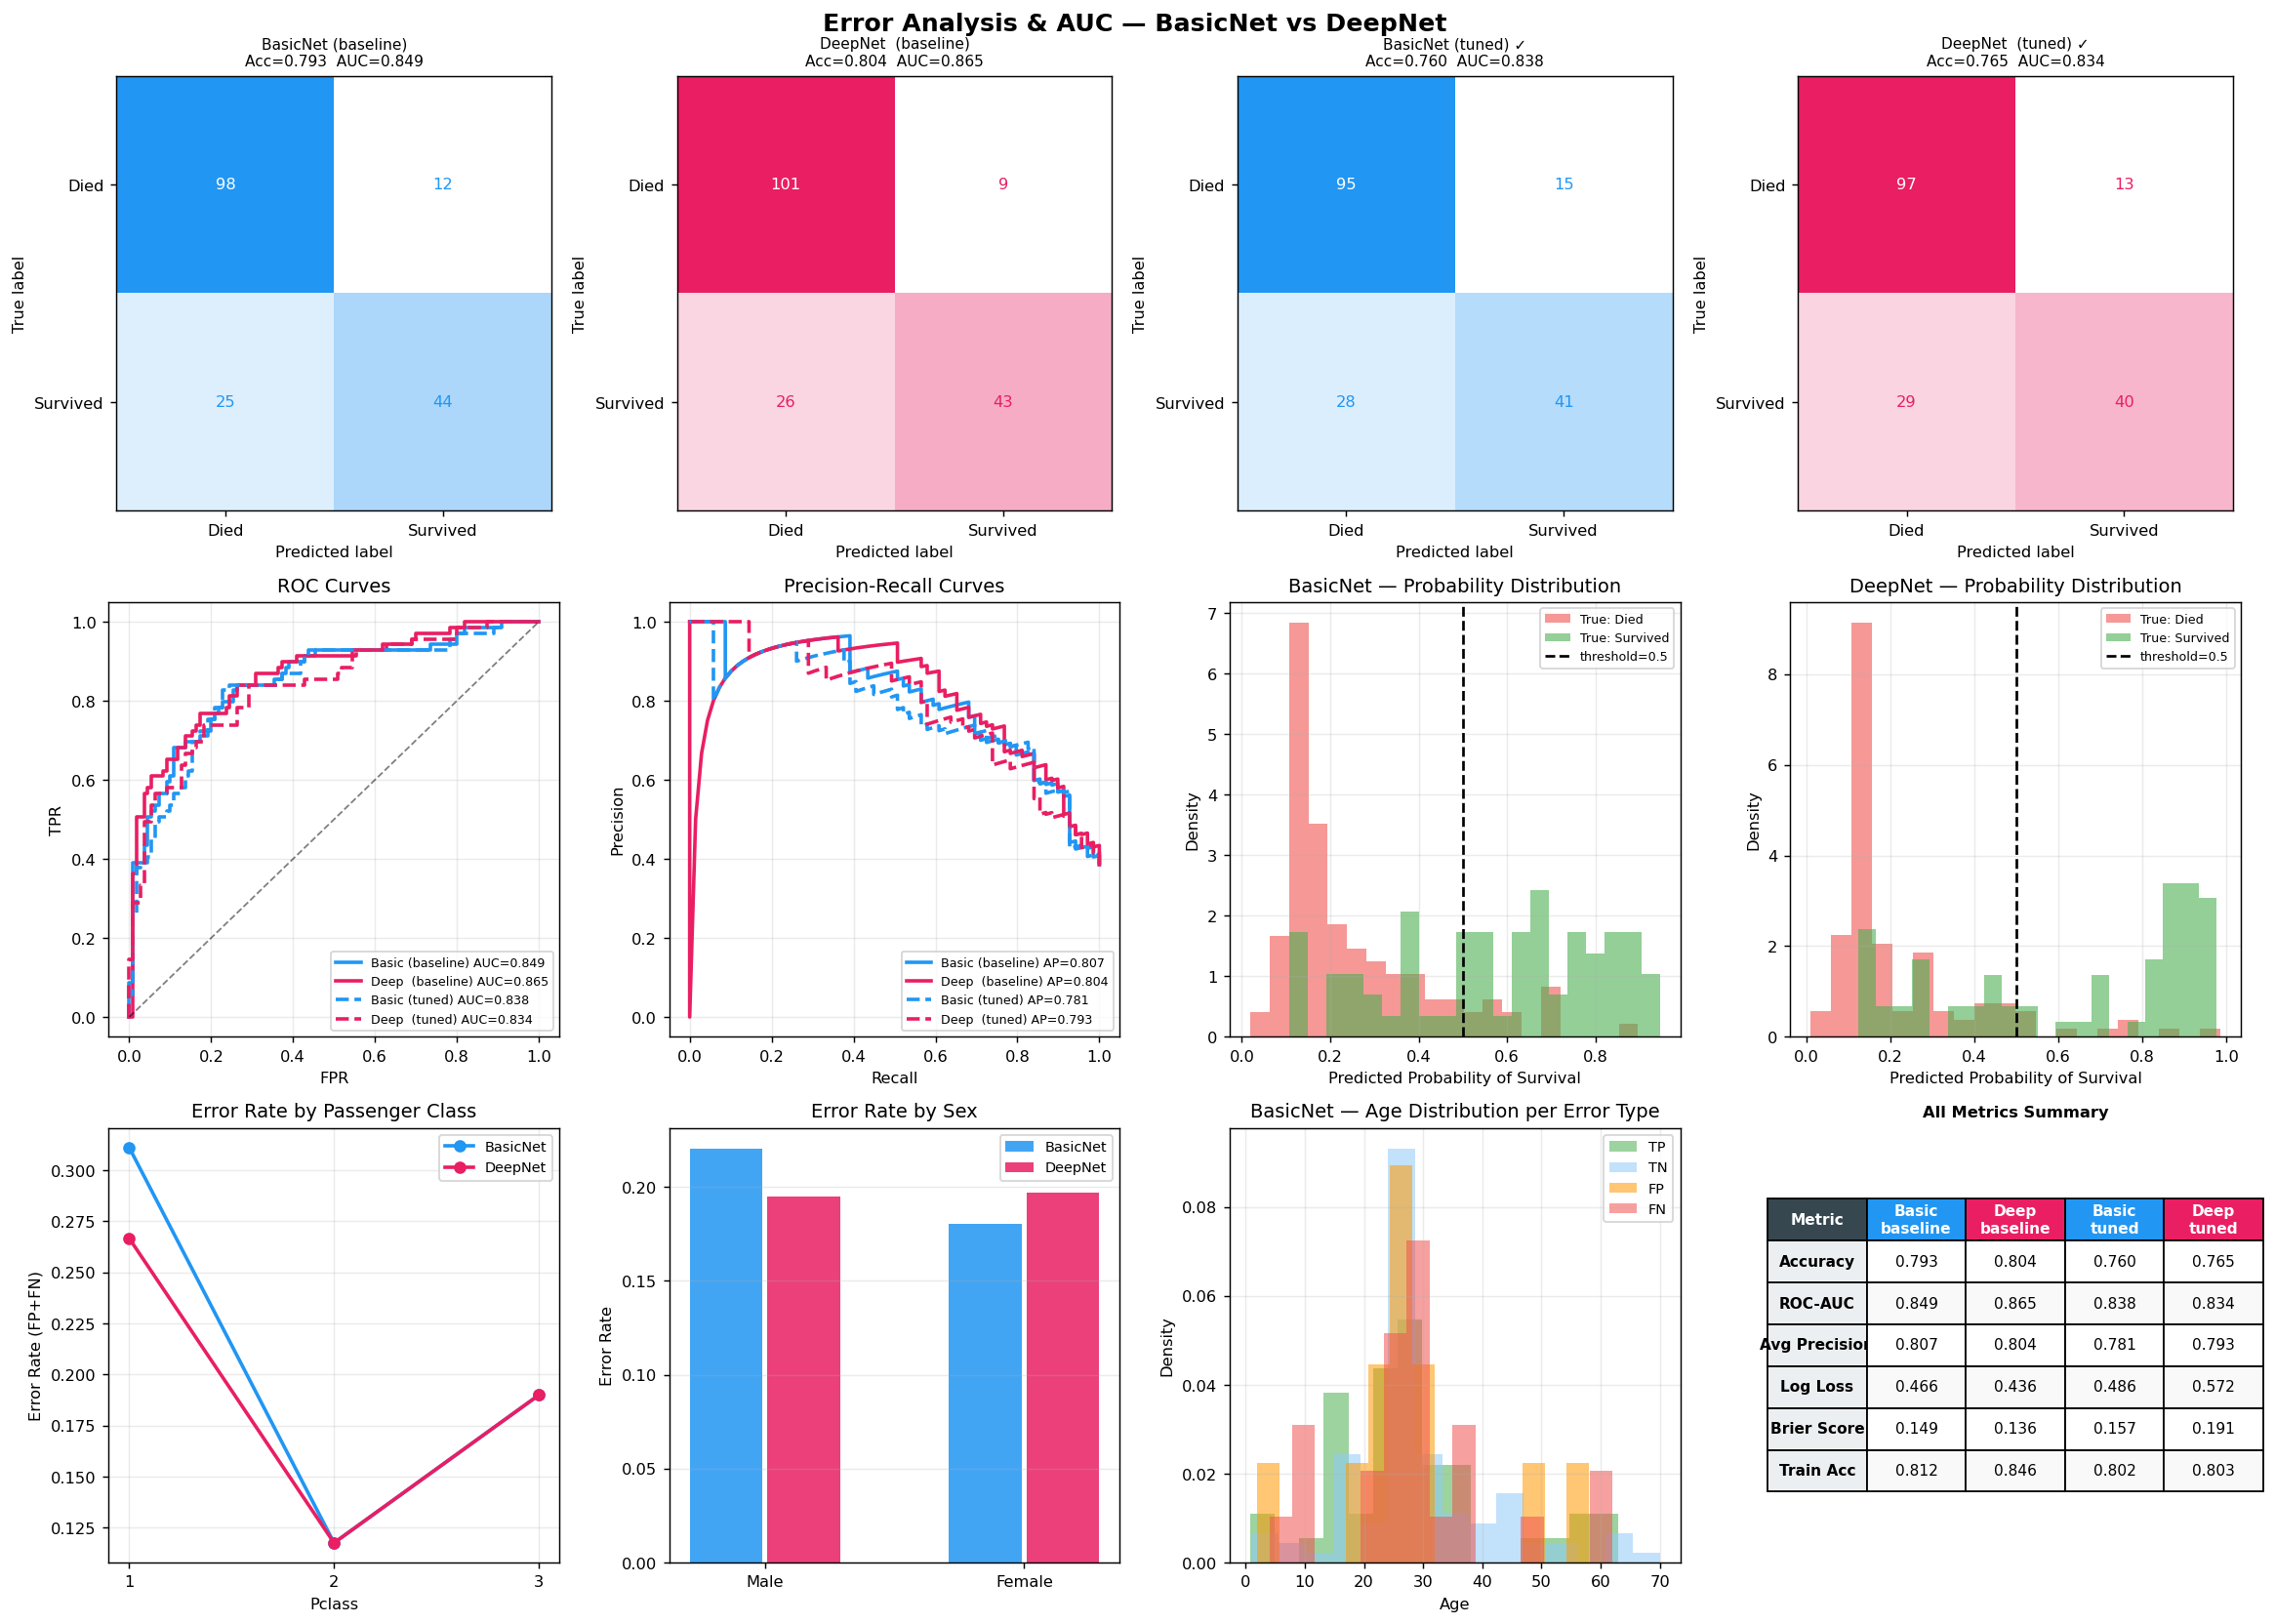

Figure 1 saved: titanic_error_auc.png


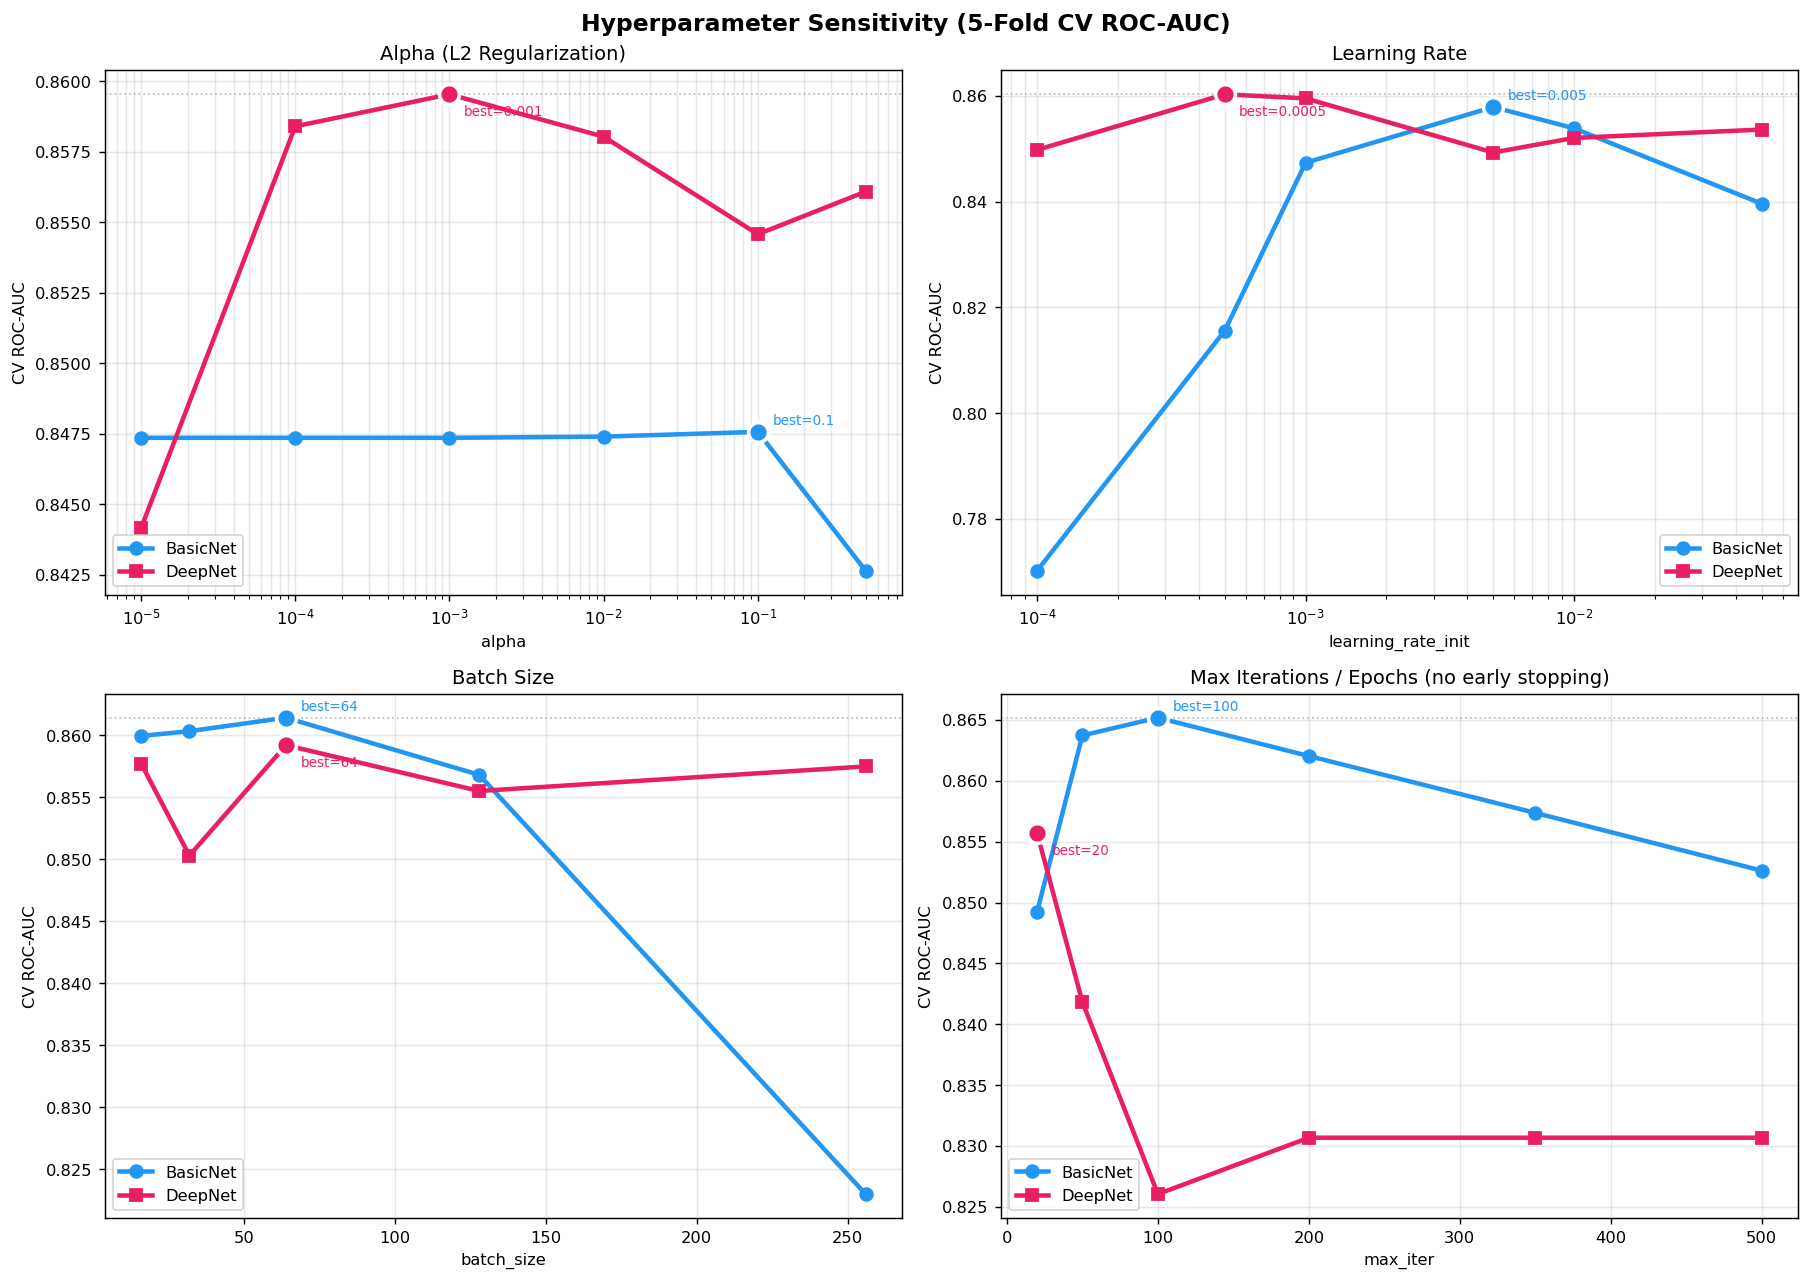

Figure 2 saved: titanic_hyperparams.png

═══════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
═══════════════════════════════════════════════════════
Model                      Accuracy      AUC   LogLoss
───────────────────────────────────────────────────────
  BasicNet (baseline)        0.7933   0.8494    0.4657
  DeepNet  (baseline)        0.8045   0.8648    0.4356
  BasicNet (tuned)           0.7598   0.8382    0.4865
  DeepNet  (tuned)           0.7654   0.8343    0.5715
═══════════════════════════════════════════════════════

Best overall model: BasicNet tuned
  Alpha:  basic=0.1  deep=0.001
  LR:     basic=0.005     deep=0.0005


In [12]:
"""
Titanic NN — Error Analysis, AUC, Confusion Matrices & Hyperparameter Tuning
JupyterLite / Pyodide compatible (scikit-learn only)
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, average_precision_score,
    log_loss, brier_score_loss,
)

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 130, "font.size": 9})

# ═══════════════════════════════════════════════════════════
# 1. DATA
# ═══════════════════════════════════════════════════════════

df = pd.read_csv("Titanic-Dataset.csv")
df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], inplace=True)
df["Age"]      = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Fare"]     = df["Fare"].fillna(df["Fare"].median())
df["Sex"]      = (df["Sex"] == "female").astype(int)
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df["FamilySize"]    = df["SibSp"] + df["Parch"] + 1
df["IsAlone"]       = (df["FamilySize"] == 1).astype(int)
df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

feature_names = df.drop("Survived", axis=1).columns.tolist()
X = df.drop("Survived", axis=1).values.astype(np.float32)
y = df["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ═══════════════════════════════════════════════════════════
# 2. BASELINE MODELS (same as before)
# ═══════════════════════════════════════════════════════════

def make_basic(**kw):
    defaults = dict(hidden_layer_sizes=(64,), activation="relu",
        solver="adam", alpha=1e-4, learning_rate_init=1e-3,
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=20, random_state=42)
    defaults.update(kw)
    return MLPClassifier(**defaults)

def make_deep(**kw):
    defaults = dict(hidden_layer_sizes=(256,128,64,32,16), activation="relu",
        solver="adam", alpha=1e-3, learning_rate="adaptive", learning_rate_init=1e-3,
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=20, random_state=42)
    defaults.update(kw)
    return MLPClassifier(**defaults)

print("Training baseline models...")
basic = make_basic(); basic.fit(X_train, y_train)
deep  = make_deep();  deep.fit(X_train, y_train)
print("Done.\n")

# ═══════════════════════════════════════════════════════════
# 3. HELPER: full metrics dict
# ═══════════════════════════════════════════════════════════

def metrics(model, Xtr, ytr, Xte, yte):
    preds   = model.predict(Xte)
    probs   = model.predict_proba(Xte)[:, 1]
    tr_pred = model.predict(Xtr)
    return dict(
        acc      = accuracy_score(yte, preds),
        auc      = roc_auc_score(yte, probs),
        ap       = average_precision_score(yte, probs),
        logloss  = log_loss(yte, probs),
        brier    = brier_score_loss(yte, probs),
        train_acc= accuracy_score(ytr, tr_pred),
        probs    = probs,
        preds    = preds,
        fpr      = roc_curve(yte, probs)[0],
        tpr      = roc_curve(yte, probs)[1],
        prec     = precision_recall_curve(yte, probs)[0],
        rec      = precision_recall_curve(yte, probs)[1],
    )

bm = metrics(basic, X_train, y_train, X_test, y_test)
dm = metrics(deep,  X_train, y_train, X_test, y_test)

# ═══════════════════════════════════════════════════════════
# 4. HYPERPARAMETER SWEEPS
# ═══════════════════════════════════════════════════════════

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── 4a. Regularization (alpha / L2)
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.5]
alpha_basic, alpha_deep = [], []
print("Sweeping alpha (regularization)...")
for a in alphas:
    alpha_basic.append(cross_val_score(make_basic(alpha=a), X_train, y_train,
                                       cv=cv, scoring="roc_auc").mean())
    alpha_deep.append(cross_val_score(make_deep(alpha=a),  X_train, y_train,
                                      cv=cv, scoring="roc_auc").mean())

# ── 4b. Learning rate
lrs = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]
lr_basic, lr_deep = [], []
print("Sweeping learning rate...")
for lr in lrs:
    lr_basic.append(cross_val_score(make_basic(learning_rate_init=lr), X_train, y_train,
                                    cv=cv, scoring="roc_auc").mean())
    lr_deep.append(cross_val_score(make_deep(learning_rate_init=lr),  X_train, y_train,
                                   cv=cv, scoring="roc_auc").mean())

# ── 4c. Batch size (via batch_size param)
batch_sizes = [16, 32, 64, 128, 256]
bs_basic, bs_deep = [], []
print("Sweeping batch size...")
for bs in batch_sizes:
    bs_basic.append(cross_val_score(make_basic(batch_size=bs), X_train, y_train,
                                    cv=cv, scoring="roc_auc").mean())
    bs_deep.append(cross_val_score(make_deep(batch_size=bs),  X_train, y_train,
                                   cv=cv, scoring="roc_auc").mean())

# ── 4d. Max iterations (capacity / overfitting)
max_iters = [20, 50, 100, 200, 350, 500]
mi_basic, mi_deep = [], []
print("Sweeping max_iter (epochs)...")
for mi in max_iters:
    # disable early stopping to see raw effect of epochs
    b = MLPClassifier(hidden_layer_sizes=(64,), activation="relu", solver="adam",
                      alpha=1e-4, learning_rate_init=1e-3, max_iter=mi,
                      early_stopping=False, random_state=42)
    d = MLPClassifier(hidden_layer_sizes=(256,128,64,32,16), activation="relu",
                      solver="adam", alpha=1e-3, learning_rate="adaptive",
                      learning_rate_init=1e-3, max_iter=mi,
                      early_stopping=False, random_state=42)
    mi_basic.append(cross_val_score(b, X_train, y_train, cv=cv, scoring="roc_auc").mean())
    mi_deep.append(cross_val_score(d, X_train, y_train, cv=cv, scoring="roc_auc").mean())

print("All sweeps done.\n")

# ── 4e. Best config from alpha + lr sweeps
best_alpha_b = alphas[np.argmax(alpha_basic)]
best_alpha_d = alphas[np.argmax(alpha_deep)]
best_lr_b    = lrs[np.argmax(lr_basic)]
best_lr_d    = lrs[np.argmax(lr_deep)]

print(f"Best alpha  — BasicNet: {best_alpha_b}  |  DeepNet: {best_alpha_d}")
print(f"Best LR     — BasicNet: {best_lr_b}     |  DeepNet: {best_lr_d}")

best_basic = make_basic(alpha=best_alpha_b, learning_rate_init=best_lr_b)
best_deep  = make_deep(alpha=best_alpha_d,  learning_rate_init=best_lr_d)
best_basic.fit(X_train, y_train)
best_deep.fit(X_train, y_train)
bbm = metrics(best_basic, X_train, y_train, X_test, y_test)
bdm = metrics(best_deep,  X_train, y_train, X_test, y_test)

print(f"\nBaseline BasicNet AUC : {bm['auc']:.4f}  →  Tuned: {bbm['auc']:.4f}")
print(f"Baseline DeepNet  AUC : {dm['auc']:.4f}  →  Tuned: {bdm['auc']:.4f}\n")

# ═══════════════════════════════════════════════════════════
# 5. ERROR ANALYSIS — per-sample inspection
# ═══════════════════════════════════════════════════════════

# Track test indices properly
np.random.seed(42)
idx    = np.arange(len(df))
y_all  = df["Survived"].values
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y_all)
Xte_raw = df.drop("Survived", axis=1).iloc[idx_te].copy()
Xte_raw["Age_orig"]     = df["Age"].iloc[idx_te].values
Xte_raw["True"]         = y_all[idx_te]
Xte_raw["Basic_pred"]   = bm["preds"]
Xte_raw["Basic_prob"]   = bm["probs"]
Xte_raw["Deep_pred"]    = dm["preds"]
Xte_raw["Deep_prob"]    = dm["probs"]

# Error categories
Xte_raw["Basic_err_type"] = "TN"
Xte_raw.loc[(Xte_raw["True"]==1) & (Xte_raw["Basic_pred"]==1), "Basic_err_type"] = "TP"
Xte_raw.loc[(Xte_raw["True"]==1) & (Xte_raw["Basic_pred"]==0), "Basic_err_type"] = "FN"
Xte_raw.loc[(Xte_raw["True"]==0) & (Xte_raw["Basic_pred"]==1), "Basic_err_type"] = "FP"

Xte_raw["Deep_err_type"] = "TN"
Xte_raw.loc[(Xte_raw["True"]==1) & (Xte_raw["Deep_pred"]==1), "Deep_err_type"] = "TP"
Xte_raw.loc[(Xte_raw["True"]==1) & (Xte_raw["Deep_pred"]==0), "Deep_err_type"] = "FN"
Xte_raw.loc[(Xte_raw["True"]==0) & (Xte_raw["Deep_pred"]==1), "Deep_err_type"] = "FP"

# ═══════════════════════════════════════════════════════════
# 6. PLOT — Figure 1: Error Analysis & AUC
# ═══════════════════════════════════════════════════════════

BLUE, PINK, GREEN, AMBER = "#2196F3", "#E91E63", "#4CAF50", "#FF9800"
ERR_COLORS = {"TP": GREEN, "TN": "#90CAF9", "FP": AMBER, "FN": "#EF5350"}

fig1, axes = plt.subplots(3, 4, figsize=(18, 13))
fig1.suptitle("Error Analysis & AUC — BasicNet vs DeepNet", fontsize=14, fontweight="bold")

# ── Row 0: Confusion matrices ─────────────────────────────
for col, (model, m, name, color) in enumerate([
    (basic, bm, "BasicNet (baseline)", BLUE),
    (deep,  dm, "DeepNet  (baseline)", PINK),
    (best_basic, bbm, "BasicNet (tuned)", BLUE),
    (best_deep,  bdm, "DeepNet  (tuned)", PINK),
]):
    ax = axes[0][col]
    cm = confusion_matrix(y_test, m["preds"])
    cmap = LinearSegmentedColormap.from_list("cm", ["white", color])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Died", "Survived"])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    tuned = " ✓" if "tuned" in name else ""
    ax.set_title(f"{name}{tuned}\nAcc={m['acc']:.3f}  AUC={m['auc']:.3f}", fontsize=8.5)

# ── Row 1: ROC + PR curves ────────────────────────────────
ax_roc = axes[1][0]
ax_pr  = axes[1][1]

for m, name, color, ls in [
    (bm,  "Basic (baseline)",  BLUE,  "-"),
    (dm,  "Deep  (baseline)",  PINK,  "-"),
    (bbm, "Basic (tuned)",     BLUE,  "--"),
    (bdm, "Deep  (tuned)",     PINK,  "--"),
]:
    ax_roc.plot(m["fpr"], m["tpr"], color=color, lw=2, ls=ls,
                label=f"{name} AUC={m['auc']:.3f}")
    ax_pr.plot(m["rec"], m["prec"], color=color, lw=2, ls=ls,
               label=f"{name} AP={m['ap']:.3f}")

ax_roc.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves"); ax_roc.legend(fontsize=7); ax_roc.grid(alpha=0.25)

ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Precision-Recall Curves"); ax_pr.legend(fontsize=7); ax_pr.grid(alpha=0.25)

# ── Row 1: Probability distributions ─────────────────────
ax_dist_b = axes[1][2]
ax_dist_d = axes[1][3]

for ax, m, name, color in [
    (ax_dist_b, bm,  "BasicNet", BLUE),
    (ax_dist_d, dm,  "DeepNet",  PINK),
]:
    ax.hist(m["probs"][y_test==0], bins=20, alpha=0.6, color="#EF5350", label="True: Died",     density=True)
    ax.hist(m["probs"][y_test==1], bins=20, alpha=0.6, color=GREEN,     label="True: Survived", density=True)
    ax.axvline(0.5, color="black", lw=1.5, ls="--", label="threshold=0.5")
    ax.set_xlabel("Predicted Probability of Survival")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} — Probability Distribution")
    ax.legend(fontsize=7); ax.grid(alpha=0.25)

# ── Row 2: Error breakdown by feature ────────────────────
# Pclass error rates
ax_pclass = axes[2][0]
for err_col, name, color in [
    ("Basic_err_type", "BasicNet", BLUE),
    ("Deep_err_type",  "DeepNet",  PINK),
]:
    fp_fn = Xte_raw[Xte_raw[err_col].isin(["FP","FN"])].groupby("Pclass").size()
    total = Xte_raw.groupby("Pclass").size()
    err_rate = (fp_fn / total).fillna(0)
    ax_pclass.plot(err_rate.index, err_rate.values, "o-", color=color, lw=2, label=name)
ax_pclass.set_xlabel("Pclass"); ax_pclass.set_ylabel("Error Rate (FP+FN)")
ax_pclass.set_title("Error Rate by Passenger Class")
ax_pclass.set_xticks([1,2,3]); ax_pclass.legend(fontsize=8); ax_pclass.grid(alpha=0.25)

# Sex error rates
ax_sex = axes[2][1]
labels = ["Male", "Female"]
for err_col, name, color in [
    ("Basic_err_type", "BasicNet", BLUE),
    ("Deep_err_type",  "DeepNet",  PINK),
]:
    rates = []
    for sex_val in [0, 1]:
        sub = Xte_raw[Xte_raw["Sex"] == sex_val]
        rates.append(sub[err_col].isin(["FP","FN"]).mean())
    ax_sex.bar(np.arange(2) + (0 if name=="BasicNet" else 0.3),
               rates, 0.28, color=color, alpha=0.85, label=name)
ax_sex.set_xticks([0.15, 1.15]); ax_sex.set_xticklabels(labels)
ax_sex.set_ylabel("Error Rate"); ax_sex.set_title("Error Rate by Sex")
ax_sex.legend(fontsize=8); ax_sex.grid(axis="y", alpha=0.25)

# Age distribution of errors
ax_age = axes[2][2]
for err_type, color in ERR_COLORS.items():
    subset = Xte_raw[Xte_raw["Basic_err_type"] == err_type]["Age_orig"]
    if len(subset) > 0:
        ax_age.hist(subset, bins=15, alpha=0.55, color=color, label=err_type, density=True)
ax_age.set_xlabel("Age"); ax_age.set_ylabel("Density")
ax_age.set_title("BasicNet — Age Distribution per Error Type")
ax_age.legend(fontsize=8); ax_age.grid(alpha=0.25)

# Metrics table
ax_tbl = axes[2][3]
ax_tbl.axis("off")
rows = [
    ["Metric",       "Basic\nbaseline", "Deep\nbaseline", "Basic\ntuned", "Deep\ntuned"],
    ["Accuracy",     f"{bm['acc']:.3f}", f"{dm['acc']:.3f}", f"{bbm['acc']:.3f}", f"{bdm['acc']:.3f}"],
    ["ROC-AUC",      f"{bm['auc']:.3f}", f"{dm['auc']:.3f}", f"{bbm['auc']:.3f}", f"{bdm['auc']:.3f}"],
    ["Avg Precision",f"{bm['ap']:.3f}",  f"{dm['ap']:.3f}",  f"{bbm['ap']:.3f}",  f"{bdm['ap']:.3f}"],
    ["Log Loss",     f"{bm['logloss']:.3f}",f"{dm['logloss']:.3f}",f"{bbm['logloss']:.3f}",f"{bdm['logloss']:.3f}"],
    ["Brier Score",  f"{bm['brier']:.3f}", f"{dm['brier']:.3f}", f"{bbm['brier']:.3f}", f"{bdm['brier']:.3f}"],
    ["Train Acc",    f"{bm['train_acc']:.3f}",f"{dm['train_acc']:.3f}",f"{bbm['train_acc']:.3f}",f"{bdm['train_acc']:.3f}"],
]
tbl = ax_tbl.table(cellText=rows[1:], colLabels=rows[0], loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 1.7)
header_colors = ["#37474f", BLUE, PINK, BLUE, PINK]
for col, hc in enumerate(header_colors):
    tbl[0, col].set_facecolor(hc)
    tbl[0, col].set_text_props(color="white", fontweight="bold")
for row in range(1, len(rows)):
    tbl[row, 0].set_facecolor("#ECEFF1")
    tbl[row, 0].set_text_props(fontweight="bold")
    for col in range(1, 5):
        tbl[row, col].set_facecolor("#f9f9f9" if row%2==0 else "white")
ax_tbl.set_title("All Metrics Summary", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("titanic_error_auc.png", dpi=140, bbox_inches="tight")
plt.show()
print("Figure 1 saved: titanic_error_auc.png")

# ═══════════════════════════════════════════════════════════
# 7. PLOT — Figure 2: Hyperparameter Sweeps
# ═══════════════════════════════════════════════════════════

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
fig2.suptitle("Hyperparameter Sensitivity (5-Fold CV ROC-AUC)", fontsize=13, fontweight="bold")

sweep_configs = [
    (axes2[0][0], alphas,      alpha_basic, alpha_deep,
     "Alpha (L2 Regularization)", "alpha", "log"),
    (axes2[0][1], lrs,         lr_basic,    lr_deep,
     "Learning Rate",             "learning_rate_init", "log"),
    (axes2[1][0], batch_sizes, bs_basic,    bs_deep,
     "Batch Size",                "batch_size", "linear"),
    (axes2[1][1], max_iters,   mi_basic,    mi_deep,
     "Max Iterations / Epochs (no early stopping)", "max_iter", "linear"),
]

for ax, xs, yb, yd, title, xlabel, scale in sweep_configs:
    ax.plot(xs, yb, "o-", color=BLUE, lw=2.5, ms=7, label="BasicNet")
    ax.plot(xs, yd, "s-", color=PINK, lw=2.5, ms=7, label="DeepNet")

    # Mark best
    best_b_idx = int(np.argmax(yb))
    best_d_idx = int(np.argmax(yd))
    ax.scatter([xs[best_b_idx]], [yb[best_b_idx]], s=120, color=BLUE,
               zorder=5, edgecolors="white", lw=2)
    ax.scatter([xs[best_d_idx]], [yd[best_d_idx]], s=120, color=PINK,
               zorder=5, edgecolors="white", lw=2)
    ax.annotate(f"best={xs[best_b_idx]}", (xs[best_b_idx], yb[best_b_idx]),
                textcoords="offset points", xytext=(8, 4), fontsize=7.5, color=BLUE)
    ax.annotate(f"best={xs[best_d_idx]}", (xs[best_d_idx], yd[best_d_idx]),
                textcoords="offset points", xytext=(8,-12), fontsize=7.5, color=PINK)

    if scale == "log":
        ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel("CV ROC-AUC")
    ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")

    # Shade under-performing region
    overall_max = max(max(yb), max(yd))
    ax.axhline(overall_max, color="gray", lw=1, ls=":", alpha=0.5)

plt.tight_layout()
plt.savefig("titanic_hyperparams.png", dpi=140, bbox_inches="tight")
plt.show()
print("Figure 2 saved: titanic_hyperparams.png")

# ═══════════════════════════════════════════════════════════
# 8. FINAL SUMMARY
# ═══════════════════════════════════════════════════════════

print("\n" + "═"*55)
print("  FINAL RESULTS SUMMARY")
print("═"*55)
print(f"{'Model':<25} {'Accuracy':>9} {'AUC':>8} {'LogLoss':>9}")
print("─"*55)
for label, m in [
    ("BasicNet (baseline)", bm),
    ("DeepNet  (baseline)", dm),
    ("BasicNet (tuned)",    bbm),
    ("DeepNet  (tuned)",    bdm),
]:
    print(f"  {label:<23} {m['acc']:>9.4f} {m['auc']:>8.4f} {m['logloss']:>9.4f}")
print("═"*55)
print(f"\nBest overall model: {'BasicNet tuned' if bbm['auc']>=bdm['auc'] else 'DeepNet tuned'}")
print(f"  Alpha:  basic={best_alpha_b}  deep={best_alpha_d}")
print(f"  LR:     basic={best_lr_b}     deep={best_lr_d}")